# Flight Delays Analysis Project


## Dataset

**Source:** Kaggle - Flight Delays Dataset  
**URL:** https://www.kaggle.com/datasets/usdot/flight-delays  



## Step 1: Install Required Libraries


In [1]:
# Install required packages
!pip install pandas numpy matplotlib seaborn kaggle



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Step 2: Download the Dataset

Make sure `kaggle.json` is in the current folder.


In [3]:
# Download dataset
import os
import json
from kaggle.api.kaggle_api_extended import KaggleApi

# Reads kaggle.json credentials and downloads the dataset. Flight-delays.zip should appear in folder after running this
with open('kaggle.json', 'r') as f:
    creds = json.load(f)
    
os.environ['KAGGLE_USERNAME'] = creds['username']
os.environ['KAGGLE_KEY'] = creds['key']

api = KaggleApi()
api.authenticate()
api.dataset_download_files('usdot/flight-delays', path='.', unzip=True)


Dataset URL: https://www.kaggle.com/datasets/usdot/flight-delays


## Step 3: Load and Explore the Dataset


In [4]:
# Load airlines data
airlines = pd.read_csv('airlines.csv')
print(f"Airlines shape: {airlines.shape}")
print(f"\nAirlines columns: {list(airlines.columns)}")
print(f"\nFirst rows:")
airlines.head()


Airlines shape: (14, 2)

Airlines columns: ['IATA_CODE', 'AIRLINE']

First rows:


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [5]:
# Load airports data
airports = pd.read_csv('airports.csv')
print(f"Airports shape: {airports.shape}")
print(f"\nAirports columns: {list(airports.columns)}")
print(f"\nFirst rows:")
airports.head()


Airports shape: (322, 7)

Airports columns: ['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE']

First rows:


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [6]:
# Load flights data
flights = pd.read_csv('flights.csv')
print(f"Flights shape: {flights.shape}")
print(f"\nFlights columns ({len(flights.columns)}):")
for i, col in enumerate(flights.columns, 1):
    print(f"  {i:2d}. {col}")


/var/folders/g5/4yhn68xj2ks9ghkkthvs4n5w0000gn/T/ipykernel_64357/558253111.py:2: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv('flights.csv')


Flights shape: (5819079, 31)

Flights columns (31):
   1. YEAR
   2. MONTH
   3. DAY
   4. DAY_OF_WEEK
   5. AIRLINE
   6. FLIGHT_NUMBER
   7. TAIL_NUMBER
   8. ORIGIN_AIRPORT
   9. DESTINATION_AIRPORT
  10. SCHEDULED_DEPARTURE
  11. DEPARTURE_TIME
  12. DEPARTURE_DELAY
  13. TAXI_OUT
  14. WHEELS_OFF
  15. SCHEDULED_TIME
  16. ELAPSED_TIME
  17. AIR_TIME
  18. DISTANCE
  19. WHEELS_ON
  20. TAXI_IN
  21. SCHEDULED_ARRIVAL
  22. ARRIVAL_TIME
  23. ARRIVAL_DELAY
  24. DIVERTED
  25. CANCELLED
  26. CANCELLATION_REASON
  27. AIR_SYSTEM_DELAY
  28. SECURITY_DELAY
  29. AIRLINE_DELAY
  30. LATE_AIRCRAFT_DELAY
  31. WEATHER_DELAY


In [7]:
# Explore flights data
flights.head()


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
# Basic info about flights
flights.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24

In [9]:
# Statistical summary
flights.describe()


,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


In [10]:
# Check for missing values
missing = flights.isnull().sum()
print("Missing values:")
print(missing[missing > 0])


Missing values:
TAIL_NUMBER              14721
DEPARTURE_TIME           86153
DEPARTURE_DELAY          86153
TAXI_OUT                 89047
WHEELS_OFF               89047
SCHEDULED_TIME               6
ELAPSED_TIME            105071
AIR_TIME                105071
WHEELS_ON                92513
TAXI_IN                  92513
ARRIVAL_TIME             92513
ARRIVAL_DELAY           105071
CANCELLATION_REASON    5729195
AIR_SYSTEM_DELAY       4755640
SECURITY_DELAY         4755640
AIRLINE_DELAY          4755640
LATE_AIRCRAFT_DELAY    4755640
WEATHER_DELAY          4755640
dtype: int64


## Step 4: Exploratory Data Analysis (EDA)


In [11]:
# Sample the data for faster EDA (use 10% of data)
flights_sample = flights.sample(frac=0.1, random_state=42)
print(f"Original flights shape: {flights.shape}")
print(f"Sampled flights shape: {flights_sample.shape}")

# Merge flights with airlines and airports data
flights_merged = flights_sample.merge(airlines, left_on='AIRLINE', right_on='IATA_CODE', how='left')
flights_merged = flights_merged.merge(airports, left_on='ORIGIN_AIRPORT', right_on='IATA_CODE', how='left', suffixes=('', '_ORIGIN'))
flights_merged = flights_merged.merge(airports, left_on='DESTINATION_AIRPORT', right_on='IATA_CODE', how='left', suffixes=('', '_DEST'))

print(f"\nMerged dataset shape: {flights_merged.shape}")
flights_merged.head()


Original flights shape: (5819079, 31)
Sampled flights shape: (581908, 31)

Merged dataset shape: (581908, 47)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE_x,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,COUNTRY,LATITUDE,LONGITUDE,IATA_CODE_DEST,AIRPORT_DEST,CITY_DEST,STATE_DEST,COUNTRY_DEST,LATITUDE_DEST,LONGITUDE_DEST
0,2015,4,7,2,EV,4900,N759EV,FWA,DTW,1340,...,USA,40.97847,-85.19515,DTW,Detroit Metropolitan Airport,Detroit,MI,USA,42.21206,-83.34884
1,2015,1,24,6,AS,611,N413AS,LAS,SEA,1910,...,USA,36.08036,-115.15233,SEA,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
2,2015,7,8,3,WN,1483,N463WN,OAK,SEA,630,...,USA,37.72129,-122.22072,SEA,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
3,2015,5,26,2,WN,193,N7745A,STL,DAL,810,...,USA,38.74769,-90.35999,DAL,Dallas Love Field,Dallas,TX,USA,32.84711,-96.85177
4,2015,7,6,1,UA,253,N213UA,IAH,HNL,1000,...,USA,29.98047,-95.33972,HNL,Honolulu International Airport,Honolulu,HI,USA,21.31869,-157.92241


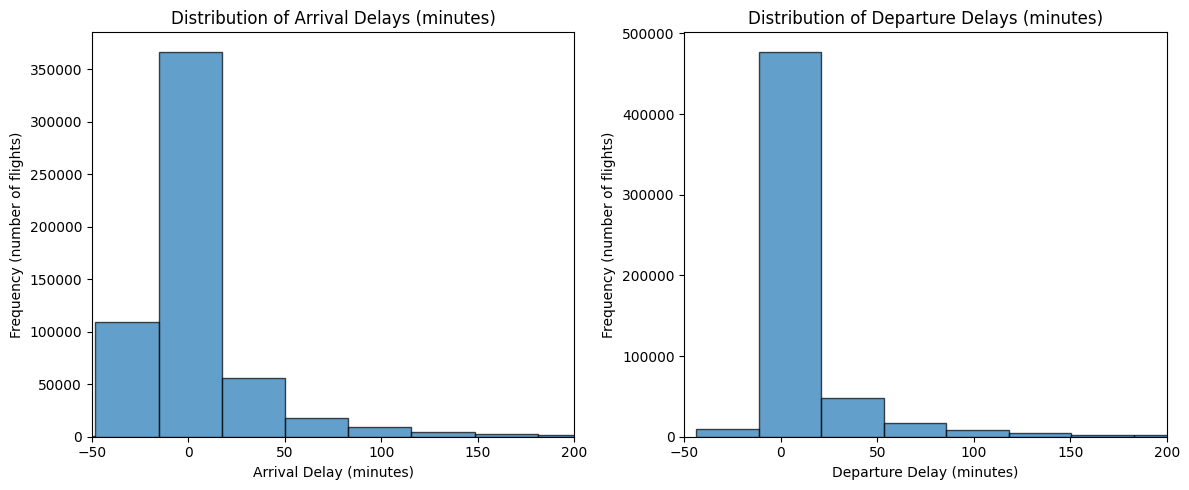

In [12]:
# Delay distribution (all delays in minutes)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(flights_sample['ARRIVAL_DELAY'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Arrival Delay (minutes)')
plt.ylabel('Frequency (number of flights)')
plt.title('Distribution of Arrival Delays (minutes)')
plt.xlim(-50, 200)

plt.subplot(1, 2, 2)
plt.hist(flights_sample['DEPARTURE_DELAY'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Departure Delay (minutes)')
plt.ylabel('Frequency (number of flights)')
plt.title('Distribution of Departure Delays (minutes)')
plt.xlim(-50, 200)

plt.tight_layout()
plt.show()


Average Delays by Airline (in minutes):
         DEPARTURE_DELAY  ARRIVAL_DELAY
AIRLINE                                
NK                 15.59          13.93
F9                 13.38          12.56
B6                 11.84           7.24
MQ                 10.22           6.54
EV                  8.59           6.50
OO                  7.73           5.88
VX                  9.74           5.33
UA                 14.18           5.26
WN                 10.69           4.50
AA                  9.11           3.66
US                  6.04           3.51
HA                  0.29           1.88
DL                  7.47           0.27
AS                  1.82          -1.03


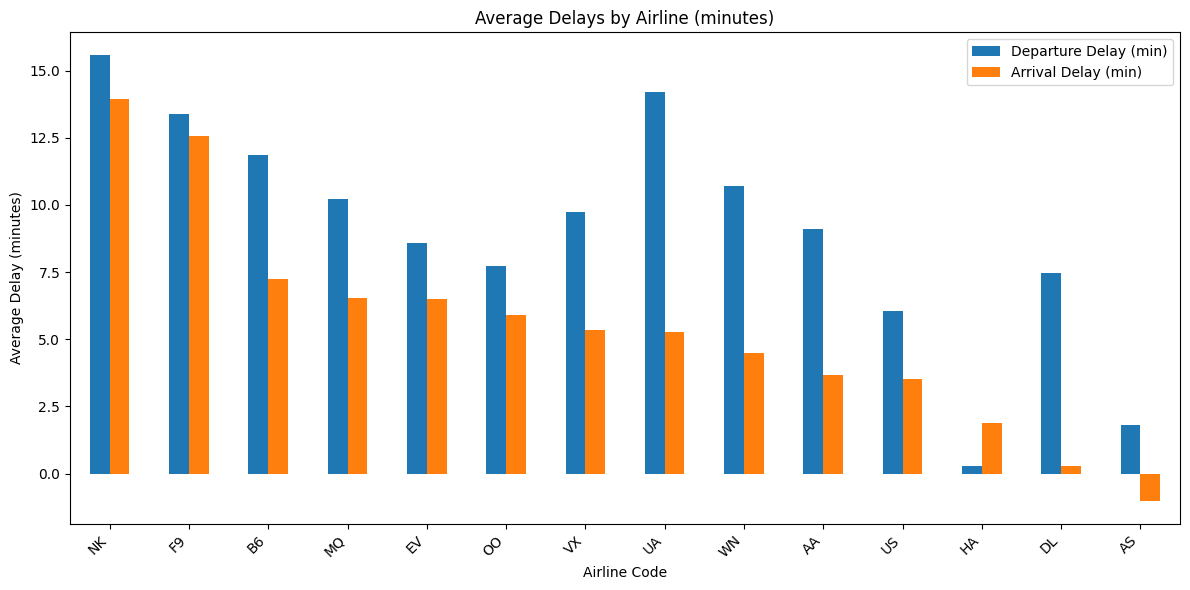

In [13]:
# Delay statistics by airline
delay_by_airline = flights_sample.groupby('AIRLINE')[['DEPARTURE_DELAY', 'ARRIVAL_DELAY']].mean().sort_values('ARRIVAL_DELAY', ascending=False)

print("Average Delays by Airline (in minutes):")
print(delay_by_airline.round(2))

plt.figure(figsize=(12, 6))
delay_by_airline.plot(kind='bar', ax=plt.gca())
plt.title('Average Delays by Airline (minutes)')
plt.xlabel('Airline Code')
plt.ylabel('Average Delay (minutes)')
plt.xticks(rotation=45, ha='right')
plt.legend(['Departure Delay (min)', 'Arrival Delay (min)'])
plt.tight_layout()
plt.show()


Average Delays by Day of Week (in minutes):
             DEPARTURE_DELAY  ARRIVAL_DELAY
DAY_OF_WEEK                                
1                      10.91           6.09
2                       9.14           4.22
3                       8.76           3.94
4                       9.91           5.61
5                       9.47           4.80
6                       8.03           2.10
7                       9.36           4.02


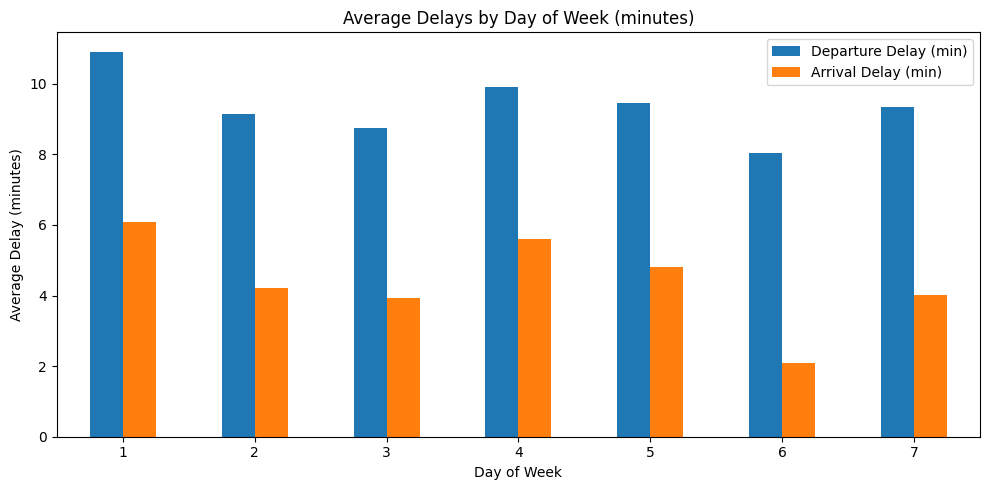

In [14]:
# Delays by day of week
if 'DAY_OF_WEEK' in flights_sample.columns:
    delay_by_day = flights_sample.groupby('DAY_OF_WEEK')[['DEPARTURE_DELAY', 'ARRIVAL_DELAY']].mean()
    
    print("Average Delays by Day of Week (in minutes):")
    print(delay_by_day.round(2))
    
    plt.figure(figsize=(10, 5))
    delay_by_day.plot(kind='bar', ax=plt.gca())
    plt.title('Average Delays by Day of Week (minutes)')
    plt.xlabel('Day of Week')
    plt.ylabel('Average Delay (minutes)')
    plt.xticks(rotation=0)
    plt.legend(['Departure Delay (min)', 'Arrival Delay (min)'])
    plt.tight_layout()
    plt.show()


Average Delays by Month (in minutes):
       DEPARTURE_DELAY  ARRIVAL_DELAY
MONTH                                
1                 9.67           5.70
2                11.84           8.33
3                 9.52           4.74
4                 8.02           3.55
5                 9.57           4.57
6                13.85           9.59
7                11.76           6.81
8                 9.83           4.56
9                 4.89          -0.80
10                5.13          -0.54
11                6.69           0.91
12               12.04           6.33


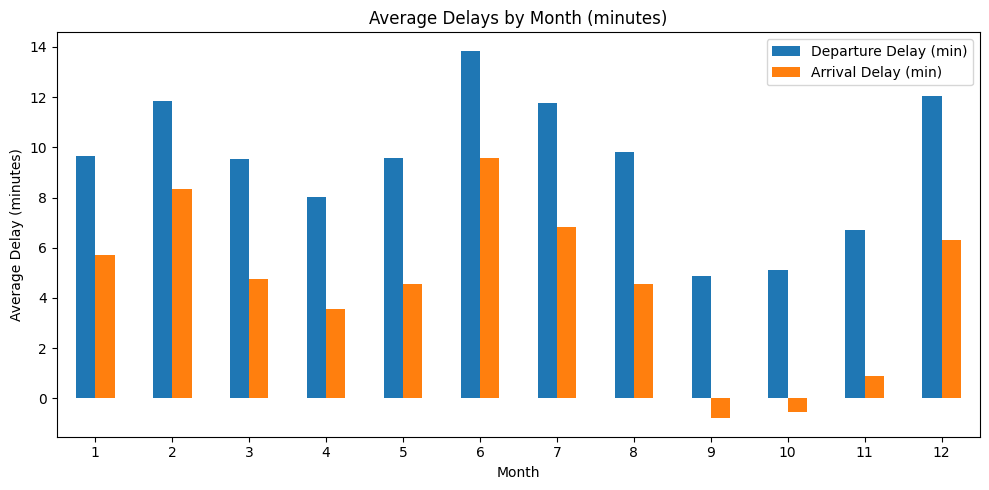

In [15]:
# Delays by month
if 'MONTH' in flights_sample.columns:
    delay_by_month = flights_sample.groupby('MONTH')[['DEPARTURE_DELAY', 'ARRIVAL_DELAY']].mean()
    
    print("Average Delays by Month (in minutes):")
    print(delay_by_month.round(2))
    
    plt.figure(figsize=(10, 5))
    delay_by_month.plot(kind='bar', ax=plt.gca())
    plt.title('Average Delays by Month (minutes)')
    plt.xlabel('Month')
    plt.ylabel('Average Delay (minutes)')
    plt.xticks(rotation=0)
    plt.legend(['Departure Delay (min)', 'Arrival Delay (min)'])
    plt.tight_layout()
    plt.show()


Top 10 Origin Cities by Average Arrival Delay (in minutes):
CITY
Aberdeen         28.17
Nantucket        21.15
Plattsburgh      20.20
St. Augustine    19.36
Binghamton       19.20
Hyannis          19.11
Kotzebue         18.42
Christiansted    18.31
Crescent City    16.95
Arcata/Eureka    16.68
Name: ARRIVAL_DELAY, dtype: float64


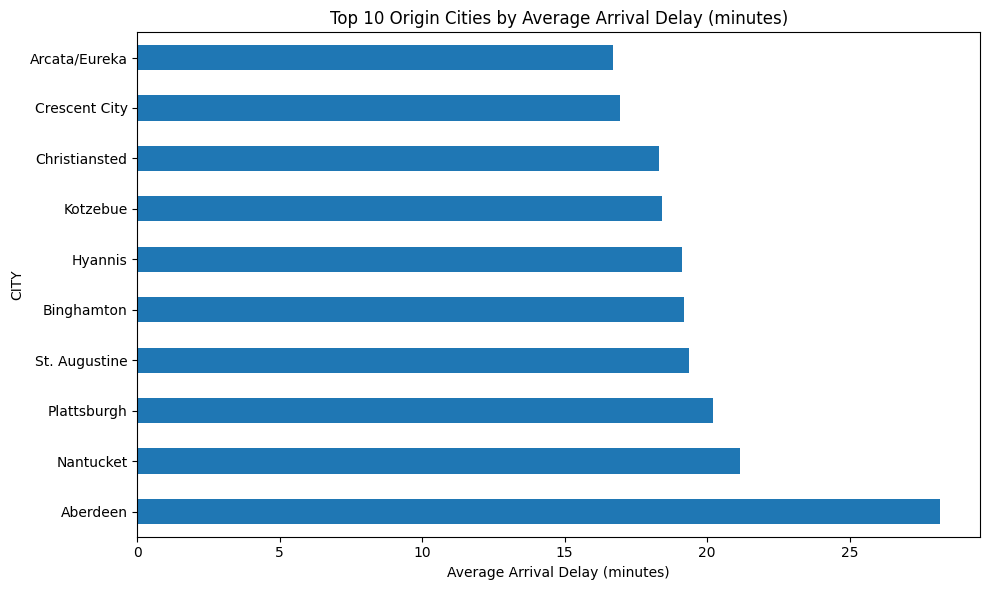

In [16]:
# Top airports with most delays
if 'CITY' in flights_merged.columns:
    top_delayed_origins = flights_merged.groupby('CITY')['ARRIVAL_DELAY'].mean().sort_values(ascending=False).head(10)
    
    print("Top 10 Origin Cities by Average Arrival Delay (in minutes):")
    print(top_delayed_origins.round(2))
    
    plt.figure(figsize=(10, 6))
    top_delayed_origins.plot(kind='barh')
    plt.title('Top 10 Origin Cities by Average Arrival Delay (minutes)')
    plt.xlabel('Average Arrival Delay (minutes)')
    plt.tight_layout()
    plt.show()


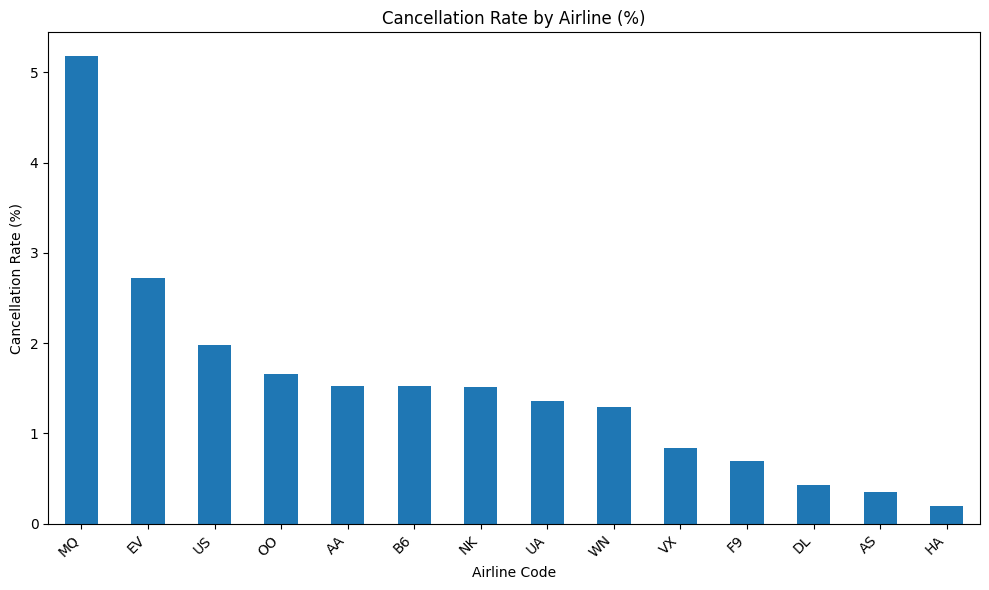

In [17]:
# Cancellation rate by airline
if 'CANCELLED' in flights_sample.columns:
    cancellation_rate = flights_sample.groupby('AIRLINE')['CANCELLED'].mean().sort_values(ascending=False) * 100
    
    plt.figure(figsize=(10, 6))
    cancellation_rate.plot(kind='bar')
    plt.title('Cancellation Rate by Airline (%)')
    plt.xlabel('Airline Code')
    plt.ylabel('Cancellation Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


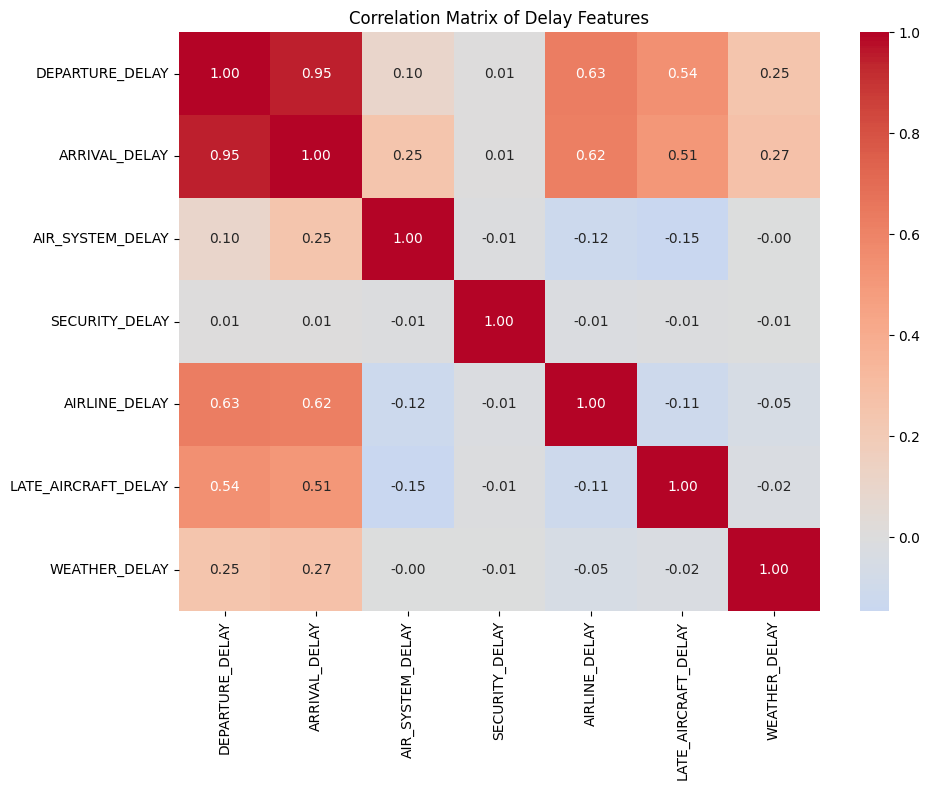

In [18]:
# Correlation matrix of delay-related features
delay_features = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 
                  'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

if all(col in flights_sample.columns for col in delay_features):
    corr = flights_sample[delay_features].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Delay Features')
    plt.tight_layout()
    plt.show()


In [19]:
# Summary statistics
print("Delay Summary Statistics (all values in minutes):")
print("\nArrival Delays (minutes):")
print(flights_sample['ARRIVAL_DELAY'].describe())
print("\nDeparture Delays (minutes):")
print(flights_sample['DEPARTURE_DELAY'].describe())


Delay Summary Statistics (all values in minutes):

Arrival Delays (minutes):
count    571355.000000
mean          4.466663
std          39.549358
min         -81.000000
25%         -13.000000
50%          -5.000000
75%           8.000000
max        1557.000000
Name: ARRIVAL_DELAY, dtype: float64

Departure Delays (minutes):
count    573268.000000
mean          9.407042
std          37.370800
min         -44.000000
25%          -5.000000
50%          -2.000000
75%           7.000000
max        1576.000000
Name: DEPARTURE_DELAY, dtype: float64


## Step 5: Machine Learning - Predict Flight Delays


In [37]:
# Install ML libraries
%pip install scikit-learn lightgbm xgboost catboost



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Import ML libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
import time


### Feature Engineering

Creating additional features to improve model performance:


In [55]:
# Prepare base data
base_cols = ['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 
             'DESTINATION_AIRPORT', 'DISTANCE', 'SCHEDULED_TIME', 'SCHEDULED_DEPARTURE', 'ARRIVAL_DELAY']

# Get available columns
available_cols = [col for col in base_cols if col in flights.columns]
ml_data = flights[available_cols].copy()
ml_data = ml_data.loc[:, ~ml_data.columns.duplicated()]

# Remove rows with missing target
ml_data = ml_data.dropna(subset=['ARRIVAL_DELAY'])

# Fill missing values
if 'SCHEDULED_TIME' in ml_data.columns:
    ml_data['SCHEDULED_TIME'] = ml_data['SCHEDULED_TIME'].fillna(ml_data['SCHEDULED_TIME'].median())

# Sort chronologically
ml_data = ml_data.sort_values(['YEAR', 'MONTH', 'DAY']).reset_index(drop=True)

print(f"Initial data shape: {ml_data.shape}")

# Feature Engineering
print("\nCreating engineered features...")

# 1. Extract hour from scheduled departure (0-23)
if 'SCHEDULED_DEPARTURE' in ml_data.columns:
    ml_data['HOUR'] = (ml_data['SCHEDULED_DEPARTURE'] // 100).astype(int).clip(0, 23)
    print("Added HOUR feature")

# 2. Create route (origin-destination)
ml_data['ROUTE'] = ml_data['ORIGIN_AIRPORT'].astype(str) + '-' + ml_data['DESTINATION_AIRPORT'].astype(str)
print("Added ROUTE feature")

# 3. Cyclical encoding for temporal features 
ml_data['HOUR_SIN'] = np.sin(2 * np.pi * ml_data['HOUR'] / 24) if 'HOUR' in ml_data.columns else 0
ml_data['HOUR_COS'] = np.cos(2 * np.pi * ml_data['HOUR'] / 24) if 'HOUR' in ml_data.columns else 0
ml_data['DAY_OF_WEEK_SIN'] = np.sin(2 * np.pi * ml_data['DAY_OF_WEEK'] / 7)
ml_data['DAY_OF_WEEK_COS'] = np.cos(2 * np.pi * ml_data['DAY_OF_WEEK'] / 7)
ml_data['MONTH_SIN'] = np.sin(2 * np.pi * ml_data['MONTH'] / 12)
ml_data['MONTH_COS'] = np.cos(2 * np.pi * ml_data['MONTH'] / 12)
print("Added cyclical features (HOUR, DAY_OF_WEEK, MONTH)")

# 4. Distance bins (short/medium/long)
if 'DISTANCE' in ml_data.columns:
    ml_data['DISTANCE_BIN'] = pd.cut(ml_data['DISTANCE'], 
                                     bins=[0, 500, 1500, 10000], 
                                     labels=['SHORT', 'MEDIUM', 'LONG']).astype(str)
    print("Added DISTANCE_BIN feature")

# 5. Interaction features
if 'HOUR' in ml_data.columns:
    ml_data['HOUR_DAY_WEEK'] = ml_data['HOUR'].astype(str) + '_' + ml_data['DAY_OF_WEEK'].astype(str)
    ml_data['AIRLINE_ROUTE'] = ml_data['AIRLINE'].astype(str) + '_' + ml_data['ROUTE'].astype(str)
    print("Added (HOUR_DAY_WEEK, AIRLINE_ROUTE)")

# 6. Calculate historical statistics 
print("  Computing historical statistics")
n_total = len(ml_data)
n_train = int(0.70 * n_total)
train_data = ml_data.iloc[:n_train].copy()

# Overall statistics from training data
overall_mean = train_data['ARRIVAL_DELAY'].mean()
overall_std = train_data['ARRIVAL_DELAY'].std()

# Historical averages (mean)
airline_avg_delay = train_data.groupby('AIRLINE')['ARRIVAL_DELAY'].mean()
origin_avg_delay = train_data.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean()
dest_avg_delay = train_data.groupby('DESTINATION_AIRPORT')['ARRIVAL_DELAY'].mean()
route_avg_delay = train_data.groupby('ROUTE')['ARRIVAL_DELAY'].mean()

# Historical medians 
airline_median_delay = train_data.groupby('AIRLINE')['ARRIVAL_DELAY'].median()
route_median_delay = train_data.groupby('ROUTE')['ARRIVAL_DELAY'].median()

# Historical standard deviations 
airline_std_delay = train_data.groupby('AIRLINE')['ARRIVAL_DELAY'].std().fillna(overall_std)
route_std_delay = train_data.groupby('ROUTE')['ARRIVAL_DELAY'].std().fillna(overall_std)

# Map historical statistics
ml_data['AIRLINE_AVG_DELAY'] = ml_data['AIRLINE'].map(airline_avg_delay).fillna(overall_mean)
ml_data['ORIGIN_AVG_DELAY'] = ml_data['ORIGIN_AIRPORT'].map(origin_avg_delay).fillna(overall_mean)
ml_data['DEST_AVG_DELAY'] = ml_data['DESTINATION_AIRPORT'].map(dest_avg_delay).fillna(overall_mean)
ml_data['ROUTE_AVG_DELAY'] = ml_data['ROUTE'].map(route_avg_delay).fillna(overall_mean)
ml_data['AIRLINE_MEDIAN_DELAY'] = ml_data['AIRLINE'].map(airline_median_delay).fillna(overall_mean)
ml_data['ROUTE_MEDIAN_DELAY'] = ml_data['ROUTE'].map(route_median_delay).fillna(overall_mean)
ml_data['AIRLINE_STD_DELAY'] = ml_data['AIRLINE'].map(airline_std_delay).fillna(overall_std)
ml_data['ROUTE_STD_DELAY'] = ml_data['ROUTE'].map(route_std_delay).fillna(overall_std)

print("Added historical statistics (mean, median, std dev)")

# 7. Route-specific temporal patterns
if 'HOUR' in ml_data.columns:
    route_hour_avg = train_data.groupby(['ROUTE', 'HOUR'])['ARRIVAL_DELAY'].mean().reset_index()
    route_hour_avg.columns = ['ROUTE', 'HOUR', 'ROUTE_HOUR_AVG']
    ml_data = ml_data.merge(route_hour_avg, on=['ROUTE', 'HOUR'], how='left')
    ml_data['ROUTE_HOUR_AVG'] = ml_data['ROUTE_HOUR_AVG'].fillna(ml_data['ROUTE_AVG_DELAY'])
    
    route_dow_avg = train_data.groupby(['ROUTE', 'DAY_OF_WEEK'])['ARRIVAL_DELAY'].mean().reset_index()
    route_dow_avg.columns = ['ROUTE', 'DAY_OF_WEEK', 'ROUTE_DOW_AVG']
    ml_data = ml_data.merge(route_dow_avg, on=['ROUTE', 'DAY_OF_WEEK'], how='left')
    ml_data['ROUTE_DOW_AVG'] = ml_data['ROUTE_DOW_AVG'].fillna(ml_data['ROUTE_AVG_DELAY'])
    
    print("Added route patterns (ROUTE_HOUR_AVG, ROUTE_DOW_AVG)")

# 8. Airport congestion features (counts flights in same hour)
if 'HOUR' in ml_data.columns:
    # Count flights at origin airport in same hour (from training data only)
    origin_hour_count = train_data.groupby(['ORIGIN_AIRPORT', 'HOUR']).size().reset_index(name='ORIGIN_HOUR_COUNT')
    ml_data = ml_data.merge(origin_hour_count, on=['ORIGIN_AIRPORT', 'HOUR'], how='left')
    ml_data['ORIGIN_HOUR_COUNT'] = ml_data['ORIGIN_HOUR_COUNT'].fillna(0)
    
    # Count flights at destination airport in same hour
    dest_hour_count = train_data.groupby(['DESTINATION_AIRPORT', 'HOUR']).size().reset_index(name='DEST_HOUR_COUNT')
    ml_data = ml_data.merge(dest_hour_count, on=['DESTINATION_AIRPORT', 'HOUR'], how='left')
    ml_data['DEST_HOUR_COUNT'] = ml_data['DEST_HOUR_COUNT'].fillna(0)
    
    print("Added airport congestion features (ORIGIN_HOUR_COUNT, DEST_HOUR_COUNT)")

# 9. Flight efficiency features
if 'SCHEDULED_TIME' in ml_data.columns and 'DISTANCE' in ml_data.columns:
    ml_data['SPEED_MILES_PER_MIN'] = ml_data['DISTANCE'] / ml_data['SCHEDULED_TIME'].replace(0, 1)
    print("Added SPEED_MILES_PER_MIN feature")

# Select final feature columns
feature_cols = ['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 
                'DISTANCE', 'SCHEDULED_TIME']

# Add engineered features
if 'HOUR' in ml_data.columns:
    feature_cols.append('HOUR')
# Cyclical encoding features
feature_cols.extend([col for col in ['HOUR_SIN', 'HOUR_COS', 'DAY_OF_WEEK_SIN', 'DAY_OF_WEEK_COS', 
                                     'MONTH_SIN', 'MONTH_COS'] if col in ml_data.columns])
# Distance bin
if 'DISTANCE_BIN' in ml_data.columns:
    feature_cols.append('DISTANCE_BIN')
# Interaction features
feature_cols.extend([col for col in ['HOUR_DAY_WEEK', 'AIRLINE_ROUTE'] if col in ml_data.columns])
# Historical statistics
if 'AIRLINE_AVG_DELAY' in ml_data.columns:
    feature_cols.extend(['AIRLINE_AVG_DELAY', 'ORIGIN_AVG_DELAY', 'DEST_AVG_DELAY', 'ROUTE_AVG_DELAY'])
    feature_cols.extend([col for col in ['AIRLINE_MEDIAN_DELAY', 'ROUTE_MEDIAN_DELAY', 
                                         'AIRLINE_STD_DELAY', 'ROUTE_STD_DELAY'] if col in ml_data.columns])
# Route temporal patterns
feature_cols.extend([col for col in ['ROUTE_HOUR_AVG', 'ROUTE_DOW_AVG'] if col in ml_data.columns])
# Airport congestion
feature_cols.extend([col for col in ['ORIGIN_HOUR_COUNT', 'DEST_HOUR_COUNT'] if col in ml_data.columns])
# Speed feature
if 'SPEED_MILES_PER_MIN' in ml_data.columns:
    feature_cols.append('SPEED_MILES_PER_MIN')

# Create X and y (y will be converted to binary in next cell)
X = ml_data[feature_cols].copy()
y_original = ml_data['ARRIVAL_DELAY'].values  # Keep original for reference

print(f"\nFinal features ({len(feature_cols)}): {feature_cols}")
print(f"Features shape: {X.shape}")
print(f"Original target (ARRIVAL_DELAY) shape: {y_original.shape}")
print(f"Date range: {ml_data['YEAR'].min()}-{ml_data['MONTH'].min()}-{ml_data['DAY'].min()} to {ml_data['YEAR'].max()}-{ml_data['MONTH'].max()}-{ml_data['DAY'].max()}")


Initial data shape: (5714008, 11)

Creating engineered features...
Added HOUR feature
Added ROUTE feature
Added cyclical features (HOUR, DAY_OF_WEEK, MONTH)
Added DISTANCE_BIN feature
Added (HOUR_DAY_WEEK, AIRLINE_ROUTE)
  Computing historical statistics
Added historical statistics (mean, median, std dev)
Added route patterns (ROUTE_HOUR_AVG, ROUTE_DOW_AVG)
Added airport congestion features (ORIGIN_HOUR_COUNT, DEST_HOUR_COUNT)
Added SPEED_MILES_PER_MIN feature

Final features (31): ['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE', 'SCHEDULED_TIME', 'HOUR', 'HOUR_SIN', 'HOUR_COS', 'DAY_OF_WEEK_SIN', 'DAY_OF_WEEK_COS', 'MONTH_SIN', 'MONTH_COS', 'DISTANCE_BIN', 'HOUR_DAY_WEEK', 'AIRLINE_ROUTE', 'AIRLINE_AVG_DELAY', 'ORIGIN_AVG_DELAY', 'DEST_AVG_DELAY', 'ROUTE_AVG_DELAY', 'AIRLINE_MEDIAN_DELAY', 'ROUTE_MEDIAN_DELAY', 'AIRLINE_STD_DELAY', 'ROUTE_STD_DELAY', 'ROUTE_HOUR_AVG', 'ROUTE_DOW_AVG', 'ORIGIN_HOUR_COUNT', 'DEST_HOUR_COUNT', 'SPEED_MILES_P

In [56]:
DELAY_THRESHOLD = 0  # minutes - flights with any delay (ARRIVAL_DELAY > 0) are considered "delayed"

print(f"Delay threshold: {DELAY_THRESHOLD} minutes")
print(f"  - Delay = 1 if ARRIVAL_DELAY > {DELAY_THRESHOLD} minutes (any positive delay)")
print(f"  - Delay = 0 if ARRIVAL_DELAY <= {DELAY_THRESHOLD} minutes (on-time or early)")

# Create binary target
y_binary = (ml_data['ARRIVAL_DELAY'] > DELAY_THRESHOLD).astype(int)

# Check class distribution
delay_count = y_binary.sum()
no_delay_count = len(y_binary) - delay_count
delay_percentage = (delay_count / len(y_binary)) * 100

print(f"\nClass Distribution:")
print(f"  No Delay (0): {no_delay_count:,} ({100-delay_percentage:.2f}%)")
print(f"  Delayed (1):   {delay_count:,} ({delay_percentage:.2f}%)")
print(f"\nUsing binary classification: y_binary shape = {y_binary.shape}")

# Keep original regression target (y_original) for reference, but use y_binary for classification
# Ensure y is integer type (0 or 1) for classification
y = y_binary.values.astype(int)

print(f"\nTarget type: {type(y)}, dtype: {y.dtype}")
print(f"Target unique values: {np.unique(y)}")
print(f"Target value counts: {np.bincount(y)}")


Delay threshold: 0 minutes
  - Delay = 1 if ARRIVAL_DELAY > 0 minutes (any positive delay)
  - Delay = 0 if ARRIVAL_DELAY <= 0 minutes (on-time or early)

Class Distribution:
  No Delay (0): 3,627,112 (63.48%)
  Delayed (1):   2,086,896 (36.52%)

Using binary classification: y_binary shape = (5714008,)

Target type: <class 'numpy.ndarray'>, dtype: int64
Target unique values: [0 1]
Target value counts: [3627112 2086896]


In [ ]:
# Split data chronologically: 70% train (earliest), 15% validation (middle), 15% test (latest)
# This preserves time dependencies - model only sees past data when predicting future
n_total = len(X)
n_train = int(0.70 * n_total)
n_val = int(0.15 * n_total)

# Chronological split (already sorted)
X_train = X.iloc[:n_train].copy()
y_train = y[:n_train].astype(int)  # Ensure binary (0 or 1)
X_val = X.iloc[n_train:n_train+n_val].copy()
y_val = y[n_train:n_train+n_val].astype(int)  # Ensure binary (0 or 1)
X_test = X.iloc[n_train+n_val:].copy()
y_test = y[n_train+n_val:].astype(int)  # Ensure binary (0 or 1)

print(f"Chronological split (preserves time dependencies):")
print(f"Train set: {X_train.shape[0]:,} samples (earliest dates)")
print(f"Validation set: {X_val.shape[0]:,} samples (middle dates)")
print(f"Test set: {X_test.shape[0]:,} samples (latest dates)")

# Verify targets are binary
print(f"\nTarget verification (should be binary 0 or 1):")
print(f"  y_train unique values: {np.unique(y_train)}")
print(f"  y_val unique values: {np.unique(y_val)}")
print(f"  y_test unique values: {np.unique(y_test)}")
print(f"  y_train dtype: {y_train.dtype}, y_val dtype: {y_val.dtype}, y_test dtype: {y_test.dtype}")

# Show date ranges for each split
train_dates = ml_data.iloc[:n_train]
val_dates = ml_data.iloc[n_train:n_train+n_val]
test_dates = ml_data.iloc[n_train+n_val:]

print(f"\nTrain date range: {train_dates['YEAR'].min()}-{train_dates['MONTH'].min()}-{train_dates['DAY'].min()} to {train_dates['YEAR'].max()}-{train_dates['MONTH'].max()}-{train_dates['DAY'].max()}")
print(f"Val date range: {val_dates['YEAR'].min()}-{val_dates['MONTH'].min()}-{val_dates['DAY'].min()} to {val_dates['YEAR'].max()}-{val_dates['MONTH'].max()}-{val_dates['DAY'].max()}")
print(f"Test date range: {test_dates['YEAR'].min()}-{test_dates['MONTH'].min()}-{test_dates['DAY'].min()} to {test_dates['YEAR'].max()}-{test_dates['MONTH'].max()}-{test_dates['DAY'].max()}")

# Calculate class weights for handling imbalanced data
pos_count = y_train.sum()
neg_count = len(y_train) - pos_count
scale_pos_weight = neg_count / pos_count
scale_pos_weight *= 2  # Ratio of negative to positive samples

print(f"\nClass imbalance handling:")
print(f"  Positive samples (delayed): {pos_count:,} ({pos_count/len(y_train)*100:.2f}%)")
print(f"  Negative samples (on-time): {neg_count:,} ({neg_count/len(y_train)*100:.2f}%)")
print(f"  scale_pos_weight for LightGBM/XGBoost: {scale_pos_weight:.4f}")

# Encode categorical features for sklearn models (XGBoost, Random Forest, HistGradientBoosting)
# Map unseen categories to dedicated UNKNOWN category to preserve all rows
label_encoders = {}
X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
X_test_encoded = X_test.copy()

print("Encoding categorical features (unseen values → UNKNOWN category)...")

# Identify categorical columns (object/string types)
categorical_cols = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE_BIN', 
                     'HOUR_DAY_WEEK', 'AIRLINE_ROUTE']
# Only encode columns that exist and are categorical
categorical_cols = [col for col in categorical_cols if col in X_train.columns and X_train[col].dtype == 'object']

for col in categorical_cols:
    le = LabelEncoder()
    X_train_encoded[col] = le.fit_transform(X_train[col].astype(str))
    
    # Get max index to create UNKNOWN category
    max_index = len(le.classes_) - 1
    unknown_index = max_index + 1
    
    # Vectorized encoding: map seen values to their index, unseen to UNKNOWN
    val_series = X_val[col].astype(str)
    val_mask = val_series.isin(le.classes_)
    
    # Create full-length array filled with UNKNOWN, then fill seen values
    val_encoded = np.full(len(val_series), unknown_index, dtype=int)
    val_encoded[val_mask] = le.transform(val_series[val_mask])
    X_val_encoded[col] = val_encoded
    
    test_series = X_test[col].astype(str)
    test_mask = test_series.isin(le.classes_)
    
    # Create full-length array filled with UNKNOWN, then fill seen values
    test_encoded = np.full(len(test_series), unknown_index, dtype=int)
    test_encoded[test_mask] = le.transform(test_series[test_mask])
    X_test_encoded[col] = test_encoded
    
    # Count unseen values
    unseen_val = set(val_series.unique()) - set(le.classes_)
    unseen_test = set(test_series.unique()) - set(le.classes_)
    val_unseen_count = (~val_mask).sum()
    test_unseen_count = (~test_mask).sum()
    
    if unseen_val or unseen_test:
        print(f"{col}: {len(unseen_val)} unique unseen values in val ({val_unseen_count:,} rows), "
              f"{len(unseen_test)} in test ({test_unseen_count:,} rows) → mapped to UNKNOWN (index {unknown_index})")
    
    label_encoders[col] = le

print(f"\nAll rows preserved: {len(X_val):,} validation, {len(X_test):,} test")

# Keep original categoricals for LightGBM and CatBoost (they handle categoricals natively)
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
X_test_cat = X_test.copy()


Chronological split (preserves time dependencies):
Train set: 3,999,805 samples (earliest dates)
Validation set: 857,101 samples (middle dates)
Test set: 857,102 samples (latest dates)

Target verification (should be binary 0 or 1):
  y_train unique values: [0 1]
  y_val unique values: [0 1]
  y_test unique values: [0 1]
  y_train dtype: int64, y_val dtype: int64, y_test dtype: int64

Train date range: 2015-1-1 to 2015-9-31
Val date range: 2015-9-1 to 2015-11-31
Test date range: 2015-11-1 to 2015-12-31

Class imbalance handling:
  Positive samples (delayed): 1,533,137 (38.33%)
  Negative samples (on-time): 2,466,668 (61.67%)
  scale_pos_weight for LightGBM/XGBoost: 1.6089
Encoding categorical features (unseen values → UNKNOWN category)...
ORIGIN_AIRPORT: 306 unique unseen values in val (482,878 rows), 0 in test (0 rows) → mapped to UNKNOWN (index 322)
DESTINATION_AIRPORT: 307 unique unseen values in val (482,878 rows), 0 in test (0 rows) → mapped to UNKNOWN (index 322)
AIRLINE_ROUTE: 6

### Model 1: LightGBM


In [ ]:
# Train LightGBM with GridSearchCV
print("Training LightGBM with GridSearchCV...")
print("This may take 30-60 minutes...")
start_time = time.time()

# Suppress LightGBM warnings (but keep training progress)
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

# Convert categorical columns to category dtype for LightGBM (auto-detects categoricals)
cat_features = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE_BIN', 
                'HOUR_DAY_WEEK', 'AIRLINE_ROUTE']
for col in cat_features:
    if col in X_train_cat.columns:
        X_train_cat[col] = X_train_cat[col].astype('category')
        X_val_cat[col] = X_val_cat[col].astype('category')
        X_test_cat[col] = X_test_cat[col].astype('category')

# Define parameter grid for GridSearchCV (limited grid for reasonable runtime)
param_grid_lgb = {
    'n_estimators': [1000, 1500, 2000],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [6, 8, 10],
    'num_leaves': [63, 127, 255],
    'min_data_in_leaf': [10, 20, 30],
    'feature_fraction': [0.7, 0.8, 0.9],
    'lambda_l1': [0, 0.1, 0.5],
    'lambda_l2': [0, 0.1, 0.5],
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 1.5, scale_pos_weight * 2.0]
}

# Create base model
lgb_base = lgb.LGBMClassifier(
    n_jobs=-1,
    random_state=42,
    verbose=-1,
    eval_metric='binary_logloss'
)

# GridSearchCV with F1 score optimization
# Note: Using smaller cv=2 and limited grid due to large dataset size
print("Performing grid search (this will take 30-60 minutes)...")
grid_search_lgb = GridSearchCV(
    lgb_base,
    param_grid_lgb,
    cv=2,  # 2-fold CV for speed (dataset is large)
    scoring='f1',  # Optimize for F1 score
    n_jobs=-1,  # Use all CPUs
    verbose=2  # Show detailed progress
)

# Fit grid search on training data
grid_search_lgb.fit(X_train_cat, y_train)

# Get best model
model_lgb = grid_search_lgb.best_estimator_

print(f"\nGrid Search completed")
print(f"Best parameters: {grid_search_lgb.best_params_}")
print(f"Best cross-validation F1 score: {grid_search_lgb.best_score_:.4f}")

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

# Predictions (binary classification)
y_pred_lgb_train = model_lgb.predict(X_train_cat)
y_pred_lgb_val = model_lgb.predict(X_val_cat)
y_pred_lgb_test = model_lgb.predict(X_test_cat)

# Probability predictions for ROC-AUC
y_pred_lgb_proba_test = model_lgb.predict_proba(X_test_cat)[:, 1]

# Classification metrics
acc_train = accuracy_score(y_train, y_pred_lgb_train)
acc_val = accuracy_score(y_val, y_pred_lgb_val)
acc_test = accuracy_score(y_test, y_pred_lgb_test)
precision_test = precision_score(y_test, y_pred_lgb_test)
recall_test = recall_score(y_test, y_pred_lgb_test)
f1_test = f1_score(y_test, y_pred_lgb_test)
roc_auc_test = roc_auc_score(y_test, y_pred_lgb_proba_test)

print(f"\nTrain Accuracy: {acc_train:.4f}")
print(f"Validation Accuracy: {acc_val:.4f}")
print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {acc_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall:    {recall_test:.4f}")
print(f"  F1 Score:  {f1_test:.4f}")
print(f"  ROC-AUC:   {roc_auc_test:.4f}")

# Feature importance
print("\nTop 10 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': X_train_cat.columns,
    'importance': model_lgb.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(10))


Training LightGBM...
[100]	valid_0's binary_logloss: 0.64988
[200]	valid_0's binary_logloss: 0.641024
[300]	valid_0's binary_logloss: 0.636655
Training time: 51.39 seconds

Train Accuracy: 0.6167
Validation Accuracy: 0.7106

Test Set Metrics:
  Accuracy:  0.6433
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000
  ROC-AUC:   0.5731

Top 10 Most Important Features:
           feature  importance
17   AIRLINE_ROUTE          62
16   HOUR_DAY_WEEK          13
1              DAY          11
26  ROUTE_HOUR_AVG          10
0            MONTH           9
27   ROUTE_DOW_AVG           7
14       MONTH_COS           5
3          AIRLINE           3
7   SCHEDULED_TIME           3
6         DISTANCE           2


/Users/rogergracia/Documents/ShaydenD/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Model 2: XGBoost


In [ ]:
# Train XGBoost (optimized hyperparameters)
print("Training XGBoost...")
start_time = time.time()

model_xgb = xgb.XGBClassifier(
    n_estimators=10000,              # More iterations
    learning_rate=0.02,              # Lower learning rate for better convergence
    max_depth=16,                     # Deeper trees
    min_child_weight=5,              # Minimum sum of instance weight in a child
    subsample=0.8,                   # Use 80% of data per tree (regularization)
    colsample_bytree=0.8,            # Use 80% of features per tree (regularization)
    colsample_bylevel=0.8,          # Use 80% of features per level
    gamma=0.1,                       # Minimum loss reduction to make split
    reg_alpha=0.1,                   # L1 regularization
    reg_lambda=0.1,                  # L2 regularization
    eval_metric='logloss',           # Binary classification metric (must be in constructor)
    scale_pos_weight=scale_pos_weight,  # Handle class imbalance
    early_stopping_rounds=300,       # Early stopping rounds (set in constructor for sklearn API)
    tree_method='hist',              # Fast histogram-based algorithm
    grow_policy='depthwise',         # Tree growth policy
    max_bin=256,                     # Number of bins for histogram
    n_jobs=-1,
    random_state=42,
    verbosity=1                      # Show training progress
)

model_xgb.fit(
    X_train_encoded, y_train,
    eval_set=[(X_val_encoded, y_val)],
    verbose=100                      # Show progress every 100 iterations
)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

# Predictions (binary classification)
y_pred_xgb_train = model_xgb.predict(X_train_encoded)
y_pred_xgb_val = model_xgb.predict(X_val_encoded)
y_pred_xgb_test = model_xgb.predict(X_test_encoded)

# Probability predictions for ROC-AUC
y_pred_xgb_proba_test = model_xgb.predict_proba(X_test_encoded)[:, 1]

# Classification metrics
acc_train = accuracy_score(y_train, y_pred_xgb_train)
acc_val = accuracy_score(y_val, y_pred_xgb_val)
acc_test = accuracy_score(y_test, y_pred_xgb_test)
precision_test = precision_score(y_test, y_pred_xgb_test)
recall_test = recall_score(y_test, y_pred_xgb_test)
f1_test = f1_score(y_test, y_pred_xgb_test)
roc_auc_test = roc_auc_score(y_test, y_pred_xgb_proba_test)

print(f"\nTrain Accuracy: {acc_train:.4f}")
print(f"Validation Accuracy: {acc_val:.4f}")
print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {acc_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall:    {recall_test:.4f}")
print(f"  F1 Score:  {f1_test:.4f}")
print(f"  ROC-AUC:   {roc_auc_test:.4f}")

# Feature importance
print("\nTop 10 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(10))


Training XGBoost...
[0]	validation_0-logloss:0.69250
[100]	validation_0-logloss:0.66598
[200]	validation_0-logloss:0.65756
[300]	validation_0-logloss:0.65172
[400]	validation_0-logloss:0.64520
[500]	validation_0-logloss:0.63944
[600]	validation_0-logloss:0.63576
[700]	validation_0-logloss:0.63567
[800]	validation_0-logloss:0.63313
[900]	validation_0-logloss:0.63242
[1000]	validation_0-logloss:0.62983
[1100]	validation_0-logloss:0.62827
[1200]	validation_0-logloss:0.62699
[1300]	validation_0-logloss:0.62588
[1400]	validation_0-logloss:0.62847
[1500]	validation_0-logloss:0.62730
[1600]	validation_0-logloss:0.62536
[1700]	validation_0-logloss:0.62333
[1800]	validation_0-logloss:0.62279
[1900]	validation_0-logloss:0.62053
[1999]	validation_0-logloss:0.62081
Training time: 195.19 seconds

Train Accuracy: 0.6798
Validation Accuracy: 0.6782

Test Set Metrics:
  Accuracy:  0.5989
  Precision: 0.4291
  Recall:    0.3774
  F1 Score:  0.4016
  ROC-AUC:   0.5778

Top 10 Most Important Features:
  

### Model 3: Decision Tree Classifier


In [ ]:
# Train Decision Tree Classifier with GridSearchCV
# Note: StandardScaler and DecisionTreeClassifier are imported in Cell 27
print("Training Decision Tree Classifier with GridSearchCV...")
print("This may take several minutes...")
start_time = time.time()

# Standardize features (similar to the example)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_val_scaled = scaler.transform(X_val_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Define parameter grid for GridSearchCV
param_grid_dt = {
    'max_depth': [15, 20, 25, 30, None],
    'min_samples_split': [5, 10, 20, 50],
    'min_samples_leaf': [2, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', {0: 1, 1: 2}]
}

# Create base model
dt_base = DecisionTreeClassifier(random_state=42)

# GridSearchCV with F1 score optimization
print("Performing grid search (this will take time)...")
grid_search_dt = GridSearchCV(
    dt_base,
    param_grid_dt,
    cv=3,  # 3-fold cross-validation for speed
    scoring='f1',  # Optimize for F1 score
    n_jobs=-1,  # Use all CPUs
    verbose=1  # Show progress
)

# Fit grid search on training data
grid_search_dt.fit(X_train_scaled, y_train)

# Get best model
model_dt = grid_search_dt.best_estimator_

train_time = time.time() - start_time
print(f"\nGrid Search completed in {train_time:.2f} seconds")
print(f"Best parameters: {grid_search_dt.best_params_}")
print(f"Best cross-validation F1 score: {grid_search_dt.best_score_:.4f}")
print(f"Tree depth: {model_dt.tree_.max_depth}, Leaves: {model_dt.get_n_leaves()}")

# Predictions (binary classification)
y_pred_dt_train = model_dt.predict(X_train_scaled)
y_pred_dt_val = model_dt.predict(X_val_scaled)
y_pred_dt_test = model_dt.predict(X_test_scaled)

# Probability predictions for ROC-AUC
y_pred_dt_proba_test = model_dt.predict_proba(X_test_scaled)[:, 1]

# Classification metrics
acc_train = accuracy_score(y_train, y_pred_dt_train)
acc_val = accuracy_score(y_val, y_pred_dt_val)
acc_test = accuracy_score(y_test, y_pred_dt_test)
precision_test = precision_score(y_test, y_pred_dt_test)
recall_test = recall_score(y_test, y_pred_dt_test)
f1_test = f1_score(y_test, y_pred_dt_test)
roc_auc_test = roc_auc_score(y_test, y_pred_dt_proba_test)

print(f"\nTrain Accuracy: {acc_train:.4f}")
print(f"Validation Accuracy: {acc_val:.4f}")
print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {acc_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall:    {recall_test:.4f}")
print(f"  F1 Score:  {f1_test:.4f}")
print(f"  ROC-AUC:   {roc_auc_test:.4f}")

# Feature importance
print("\nTop 10 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': X_train_encoded.columns,
    'importance': model_dt.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(10))


Training Decision Tree Classifier...
Training time: 78.99 seconds

Train Accuracy: 0.8250
Validation Accuracy: 0.5654

Test Set Metrics:
  Accuracy:  0.5468
  Precision: 0.3817
  Recall:    0.4366
  F1 Score:  0.4073
  ROC-AUC:   0.5298

Top 10 Most Important Features:
                feature  importance
26       ROUTE_HOUR_AVG    0.160618
1                   DAY    0.128988
27        ROUTE_DOW_AVG    0.090569
30  SPEED_MILES_PER_MIN    0.062702
16        HOUR_DAY_WEEK    0.047927
7        SCHEDULED_TIME    0.045835
29      DEST_HOUR_COUNT    0.036182
17        AIRLINE_ROUTE    0.035945
28    ORIGIN_HOUR_COUNT    0.035877
25      ROUTE_STD_DELAY    0.033224


### Model 4: CatBoost


In [46]:
# Train CatBoost (optimized hyperparameters)
print("Training CatBoost...")
start_time = time.time()

cat_features = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE_BIN', 
                'HOUR_DAY_WEEK', 'AIRLINE_ROUTE']
cat_indices = [X_train_cat.columns.get_loc(c) for c in cat_features if c in X_train_cat.columns]

model_cb = cb.CatBoostClassifier(
    iterations=2000,              # More iterations
    learning_rate=0.005,            # Lower learning rate for better convergence
    depth=16,                       # Deeper trees
    l2_leaf_reg=3,                 # L2 regularization to prevent overfitting
    random_strength=1,             # Randomness in scoring splits
    bagging_temperature=1,         # Controls intensity of Bayesian bagging
    border_count=128,              # Number of splits for numerical features
    cat_features=cat_indices,
    loss_function='Logloss',       # Binary classification loss
    eval_metric='Logloss',
    random_seed=42,
    verbose=100,                   # Show progress every 100 iterations
    early_stopping_rounds=200,     # More patience
    use_best_model=True            # Use best iteration from validation
)

model_cb.fit(
    X_train_cat, y_train,
    eval_set=(X_val_cat, y_val),
    early_stopping_rounds=100,
    verbose=100
)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")

# Predictions (binary classification)
y_pred_cb_train = model_cb.predict(X_train_cat)
y_pred_cb_val = model_cb.predict(X_val_cat)
y_pred_cb_test = model_cb.predict(X_test_cat)

# Probability predictions for ROC-AUC
y_pred_cb_proba_test = model_cb.predict_proba(X_test_cat)[:, 1]

# Classification metrics
acc_train = accuracy_score(y_train, y_pred_cb_train)
acc_val = accuracy_score(y_val, y_pred_cb_val)
acc_test = accuracy_score(y_test, y_pred_cb_test)
precision_test = precision_score(y_test, y_pred_cb_test)
recall_test = recall_score(y_test, y_pred_cb_test)
f1_test = f1_score(y_test, y_pred_cb_test)
roc_auc_test = roc_auc_score(y_test, y_pred_cb_proba_test)

print(f"\nTrain Accuracy: {acc_train:.4f}")
print(f"Validation Accuracy: {acc_val:.4f}")
print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {acc_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall:    {recall_test:.4f}")
print(f"  F1 Score:  {f1_test:.4f}")
print(f"  ROC-AUC:   {roc_auc_test:.4f}")

# Feature importance
print("\nTop 10 Most Important Features:")
feature_importance = pd.DataFrame({
    'feature': X_train_cat.columns,
    'importance': model_cb.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(10))


Training CatBoost...
0:	learn: 0.6924040	test: 0.6928498	best: 0.6928498 (0)	total: 5.32s	remaining: 2h 57m 13s
100:	learn: 0.6430642	test: 0.6608873	best: 0.6608873 (100)	total: 9m 2s	remaining: 2h 49m 54s
200:	learn: 0.6231453	test: 0.6404170	best: 0.6404170 (200)	total: 16m 47s	remaining: 2h 30m 13s
300:	learn: 0.6132280	test: 0.6294711	best: 0.6294711 (300)	total: 24m 29s	remaining: 2h 18m 17s
400:	learn: 0.6072472	test: 0.6229617	best: 0.6229617 (400)	total: 32m 5s	remaining: 2h 7m 57s
500:	learn: 0.6027396	test: 0.6187637	best: 0.6187637 (500)	total: 40m 13s	remaining: 2h 21s
600:	learn: 0.5986392	test: 0.6159953	best: 0.6159953 (600)	total: 48m 23s	remaining: 1h 52m 38s
700:	learn: 0.5947599	test: 0.6143572	best: 0.6143345 (697)	total: 56m 55s	remaining: 1h 45m 28s
800:	learn: 0.5911286	test: 0.6127381	best: 0.6127180 (798)	total: 1h 6m 12s	remaining: 1h 39m 6s
900:	learn: 0.5873508	test: 0.6116905	best: 0.6116208 (888)	total: 1h 17m 50s	remaining: 1h 34m 56s
1000:	learn: 0.5834

### Model 5: HistGradientBoostingClassifier


In [ ]:
# Train HistGradientBoostingClassifier with GridSearchCV
# Ensure imports are available
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import HistGradientBoostingClassifier

print("Training HistGradientBoostingClassifier with GridSearchCV...")
print("This may take 30-60 minutes (reduced parameter grid: 24 combinations)...")
start_time = time.time()

# Define parameter grid for GridSearchCV (reduced for faster execution)
# Reduced from 648 combinations to 24 combinations (27x faster)
param_grid_hgb = {
    'max_iter': [500, 800],           # Removed 300 (too slow with low learning_rate)
    'learning_rate': [0.05, 0.1],      # Removed 0.01 (too slow)
    'max_depth': [7, 9, 11],           # Removed 5 (too shallow)
    'min_samples_leaf': [10, 20],      # Removed 5 (less regularized)
    'l2_regularization': [0, 0.1],     # Removed 0.5 (less aggressive)
    'max_bins': [255]                  # Use better binning (128 is usually too coarse)
}

# Create base model
hgb_base = HistGradientBoostingClassifier(
    random_state=42,
    verbose=0
)

# GridSearchCV with F1 score optimization
print("Performing grid search (this will take time)...")
grid_search_hgb = GridSearchCV(
    hgb_base,
    param_grid_hgb,
    cv=3,  # 3-fold cross-validation
    scoring='f1',  # Optimize for F1 score
    n_jobs=-1,  # Use all CPUs
    verbose=2  # Show detailed progress
)

# Fit grid search on training data
grid_search_hgb.fit(X_train_encoded, y_train)

# Get best model
model_hgb = grid_search_hgb.best_estimator_

train_time = time.time() - start_time
print(f"\nGrid Search completed in {train_time:.2f} seconds ({train_time/60:.2f} minutes)")
print(f"Best parameters: {grid_search_hgb.best_params_}")
print(f"Best cross-validation F1 score: {grid_search_hgb.best_score_:.4f}")

# Predictions (binary classification)
y_pred_hgb_train = model_hgb.predict(X_train_encoded)
y_pred_hgb_val = model_hgb.predict(X_val_encoded)
y_pred_hgb_test = model_hgb.predict(X_test_encoded)

# Probability predictions for ROC-AUC
y_pred_hgb_proba_test = model_hgb.predict_proba(X_test_encoded)[:, 1]

# Classification metrics
acc_train = accuracy_score(y_train, y_pred_hgb_train)
acc_val = accuracy_score(y_val, y_pred_hgb_val)
acc_test = accuracy_score(y_test, y_pred_hgb_test)
precision_test = precision_score(y_test, y_pred_hgb_test)
recall_test = recall_score(y_test, y_pred_hgb_test)
f1_test = f1_score(y_test, y_pred_hgb_test)
roc_auc_test = roc_auc_score(y_test, y_pred_hgb_proba_test)

print(f"\nTrain Accuracy: {acc_train:.4f}")
print(f"Validation Accuracy: {acc_val:.4f}")
print(f"\nTest Set Metrics:")
print(f"  Accuracy:  {acc_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall:    {recall_test:.4f}")
print(f"  F1 Score:  {f1_test:.4f}")
print(f"  ROC-AUC:   {roc_auc_test:.4f}")


Training HistGradientBoostingClassifier with GridSearchCV...
This may take 20-40 minutes...
Performing grid search (this will take time)...
Fitting 3 folds for each of 648 candidates, totalling 1944 fits
[CV] END l2_regularization=0, learning_rate=0.01, max_bins=128, max_depth=5, max_iter=300, min_samples_leaf=20; total time=20.3min
[CV] END l2_regularization=0, learning_rate=0.01, max_bins=128, max_depth=5, max_iter=300, min_samples_leaf=10; total time=21.0min
[CV] END l2_regularization=0, learning_rate=0.01, max_bins=128, max_depth=5, max_iter=300, min_samples_leaf=20; total time=21.0min
[CV] END l2_regularization=0, learning_rate=0.01, max_bins=128, max_depth=5, max_iter=300, min_samples_leaf=5; total time=21.0min
[CV] END l2_regularization=0, learning_rate=0.01, max_bins=128, max_depth=5, max_iter=300, min_samples_leaf=10; total time=21.2min
[CV] END l2_regularization=0, learning_rate=0.01, max_bins=128, max_depth=5, max_iter=300, min_samples_leaf=5; total time=21.2min
[CV] END l2_

KeyboardInterrupt: 

In [ ]:
# Save all trained models for later reuse
import pickle
import os
from datetime import datetime

# Create models directory if it doesn't exist
models_dir = 'saved_models'
os.makedirs(models_dir, exist_ok=True)

# Current timestamp for file naming
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

print("Saving trained models...")
print("=" * 70)

# Get historical statistics for predictions (calculated from training data)
n_total = len(ml_data)
n_train = int(0.70 * n_total)
train_data_for_stats = ml_data.iloc[:n_train].copy()

overall_mean = train_data_for_stats['ARRIVAL_DELAY'].mean()
overall_std = train_data_for_stats['ARRIVAL_DELAY'].std()

# Save historical statistics for feature engineering during prediction
historical_stats = {
    'overall_mean': overall_mean,
    'overall_std': overall_std,
    'airline_avg_delay': train_data_for_stats.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().to_dict(),
    'origin_avg_delay': train_data_for_stats.groupby('ORIGIN_AIRPORT')['ARRIVAL_DELAY'].mean().to_dict(),
    'dest_avg_delay': train_data_for_stats.groupby('DESTINATION_AIRPORT')['ARRIVAL_DELAY'].mean().to_dict(),
    'route_avg_delay': train_data_for_stats.groupby('ROUTE')['ARRIVAL_DELAY'].mean().to_dict(),
    'airline_median_delay': train_data_for_stats.groupby('AIRLINE')['ARRIVAL_DELAY'].median().to_dict(),
    'route_median_delay': train_data_for_stats.groupby('ROUTE')['ARRIVAL_DELAY'].median().to_dict(),
    'airline_std_delay': train_data_for_stats.groupby('AIRLINE')['ARRIVAL_DELAY'].std().fillna(overall_std).to_dict(),
    'route_std_delay': train_data_for_stats.groupby('ROUTE')['ARRIVAL_DELAY'].std().fillna(overall_std).to_dict(),
}

# Save route-hour and route-day-of-week averages
route_hour_avg_df = train_data_for_stats.groupby(['ROUTE', 'HOUR'])['ARRIVAL_DELAY'].mean().reset_index()
route_dow_avg_df = train_data_for_stats.groupby(['ROUTE', 'DAY_OF_WEEK'])['ARRIVAL_DELAY'].mean().reset_index()
origin_hour_count_df = train_data_for_stats.groupby(['ORIGIN_AIRPORT', 'HOUR']).size().reset_index(name='ORIGIN_HOUR_COUNT')
dest_hour_count_df = train_data_for_stats.groupby(['DESTINATION_AIRPORT', 'HOUR']).size().reset_index(name='DEST_HOUR_COUNT')

historical_stats['route_hour_avg'] = route_hour_avg_df.set_index(['ROUTE', 'HOUR'])['ARRIVAL_DELAY'].to_dict()
historical_stats['route_dow_avg'] = route_dow_avg_df.set_index(['ROUTE', 'DAY_OF_WEEK'])['ARRIVAL_DELAY'].to_dict()
historical_stats['origin_hour_count'] = origin_hour_count_df.set_index(['ORIGIN_AIRPORT', 'HOUR'])['ORIGIN_HOUR_COUNT'].to_dict()
historical_stats['dest_hour_count'] = dest_hour_count_df.set_index(['DESTINATION_AIRPORT', 'HOUR'])['DEST_HOUR_COUNT'].to_dict()

# Save each model with its necessary preprocessing components
models_to_save = {
    'lightgbm': {
        'model': model_lgb,
        'scaler': None,  # LightGBM doesn't need scaling
        'encoder': None,  # Uses category dtype directly
        'features': 'X_train_cat'
    },
    'xgboost': {
        'model': model_xgb,
        'scaler': None,  # XGBoost doesn't need scaling
        'encoder': label_encoders,  # Needs label encoders
        'features': 'X_train_encoded'
    },
    'decision_tree': {
        'model': model_dt,
        'scaler': scaler,  # Needs StandardScaler
        'encoder': label_encoders,  # Needs label encoders
        'features': 'X_train_scaled'
    },
    'catboost': {
        'model': model_cb,
        'scaler': None,  # CatBoost doesn't need scaling
        'encoder': None,  # Uses category dtype directly
        'features': 'X_train_cat'
    },
    'histgradientboosting': {
        'model': model_hgb,
        'scaler': None,  # HistGradientBoosting doesn't need scaling
        'encoder': label_encoders,  # Needs label encoders
        'features': 'X_train_encoded'
    }
}

# Save each model and its preprocessing components
saved_files = {}
for model_name, model_dict in models_to_save.items():
    filename = f"{models_dir}/{model_name}_{timestamp}.pkl"
    
    save_data = {
        'model': model_dict['model'],
        'scaler': model_dict['scaler'],
        'encoders': model_dict['encoder'],
        'feature_names': list(X_train.columns),  # Save feature names for reference
        'threshold': DELAY_THRESHOLD,  # Save the delay threshold used
        'scale_pos_weight': scale_pos_weight if model_name in ['lightgbm', 'xgboost'] else None,
        'historical_stats': historical_stats,  # Save historical stats for feature engineering
        'timestamp': timestamp
    }
    
    with open(filename, 'wb') as f:
        pickle.dump(save_data, f)
    
    saved_files[model_name] = filename
    file_size = os.path.getsize(filename) / (1024 * 1024)  # Size in MB
    print(f"{model_name:20s} saved: {filename} ({file_size:.2f} MB)")

print("=" * 70)
print(f"\nAll models saved to '{models_dir}/' directory")
print(f"To load a model later, use:")
print(f"  with open('{saved_files['lightgbm']}', 'rb') as f:")
print(f"      saved_data = pickle.load(f)")
print(f"      model = saved_data['model']")

# Also save a summary file with model info
summary = {
    'timestamp': timestamp,
    'delay_threshold': DELAY_THRESHOLD,
    'scale_pos_weight': scale_pos_weight,
    'feature_count': len(X_train.columns),
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'test_samples': len(X_test),
    'feature_names': list(X_train.columns),
    'saved_files': saved_files,
    'historical_stats': historical_stats
}

summary_file = f"{models_dir}/model_summary_{timestamp}.pkl"
with open(summary_file, 'wb') as f:
    pickle.dump(summary, f)

print(f"\nModel summary saved: {summary_file}")


Saving trained models...
lightgbm             saved: saved_models/lightgbm_20251031_120240.pkl (1.82 MB)
xgboost              saved: saved_models/xgboost_20251031_120240.pkl (32.24 MB)
decision_tree        saved: saved_models/decision_tree_20251031_120240.pkl (80.46 MB)
catboost             saved: saved_models/catboost_20251031_120240.pkl (3987.18 MB)
histgradientboosting saved: saved_models/histgradientboosting_20251031_120240.pkl (3.35 MB)

All models saved to 'saved_models/' directory
To load a model later, use:
  with open('saved_models/lightgbm_20251031_120240.pkl', 'rb') as f:
      saved_data = pickle.load(f)
      model = saved_data['model']

Model summary saved: saved_models/model_summary_20251031_120240.pkl

All models can be reloaded without retraining!


In [ ]:
# Optimize prediction thresholds for each model
# Find the threshold that maximizes F1 score on validation set

print("Finding optimal thresholds for each model (maximizing F1 score on validation set)...")
print("=" * 70)

from sklearn.metrics import f1_score

# Get probability predictions on validation set for all models
y_proba_val_models = {
    'LightGBM': model_lgb.predict_proba(X_val_cat)[:, 1],
    'XGBoost': model_xgb.predict_proba(X_val_encoded)[:, 1],
    'Decision Tree': model_dt.predict_proba(X_val_scaled)[:, 1],
    'CatBoost': model_cb.predict_proba(X_val_cat)[:, 1],
    'HistGradientBoosting': model_hgb.predict_proba(X_val_encoded)[:, 1]
}

# Find optimal threshold for each model
optimal_thresholds = {}
thresholds_to_try = np.arange(0.1, 0.9, 0.01)

for model_name, y_proba_val in y_proba_val_models.items():
    best_threshold = 0.5
    best_f1 = 0
    
    for threshold in thresholds_to_try:
        y_pred_thresh = (y_proba_val >= threshold).astype(int)
        f1 = f1_score(y_val, y_pred_thresh)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
    
    optimal_thresholds[model_name] = best_threshold
    print(f"{model_name:20s}: Optimal threshold = {best_threshold:.3f} (F1 = {best_f1:.4f})")

print("=" * 70)

# Apply optimal thresholds to test set predictions
y_pred_lgb_test_opt = (y_pred_lgb_proba_test >= optimal_thresholds['LightGBM']).astype(int)
y_pred_xgb_test_opt = (y_pred_xgb_proba_test >= optimal_thresholds['XGBoost']).astype(int)
y_pred_dt_test_opt = (y_pred_dt_proba_test >= optimal_thresholds['Decision Tree']).astype(int)
y_pred_cb_test_opt = (y_pred_cb_proba_test >= optimal_thresholds['CatBoost']).astype(int)
y_pred_hgb_test_opt = (y_pred_hgb_proba_test >= optimal_thresholds['HistGradientBoosting']).astype(int)

print("\nUpdated predictions using optimal thresholds:")
print(f"  LightGBM: threshold {optimal_thresholds['LightGBM']:.3f}")
print(f"  XGBoost: threshold {optimal_thresholds['XGBoost']:.3f}")
print(f"  Decision Tree: threshold {optimal_thresholds['Decision Tree']:.3f}")
print(f"  CatBoost: threshold {optimal_thresholds['CatBoost']:.3f}")
print(f"  HistGradientBoosting: threshold {optimal_thresholds['HistGradientBoosting']:.3f}")


### Model Comparison


Loading all saved models and preparing for comparison...
Found lightgbm: lightgbm_20251031_120240.pkl
Found xgboost: xgboost_20251031_120240.pkl
Found decision_tree: decision_tree_20251031_120240.pkl
Found catboost: catboost_20251031_120240.pkl
Found histgradientboosting: histgradientboosting_20251031_120240.pkl

Predictions made for all loaded models

Finding optimal thresholds on validation set...
Optimal thresholds calculated

MODEL COMPARISON
Model Comparison (Test Set - Binary Classification):
Delay Threshold: >0 minutes
Using optimized prediction thresholds (maximizing F1 score)
               Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
             XGBoost    0.4546     0.3798  0.8359    0.5223   0.5778
HistGradientBoosting    0.4356     0.3755  0.8788    0.5262   0.5769
            CatBoost    0.5158     0.3966  0.6858    0.5026   0.5750
            LightGBM    0.4080     0.3687  0.9266    0.5275   0.5731
       Decision Tree    0.4840     0.3720  0.6489    0.4729   0

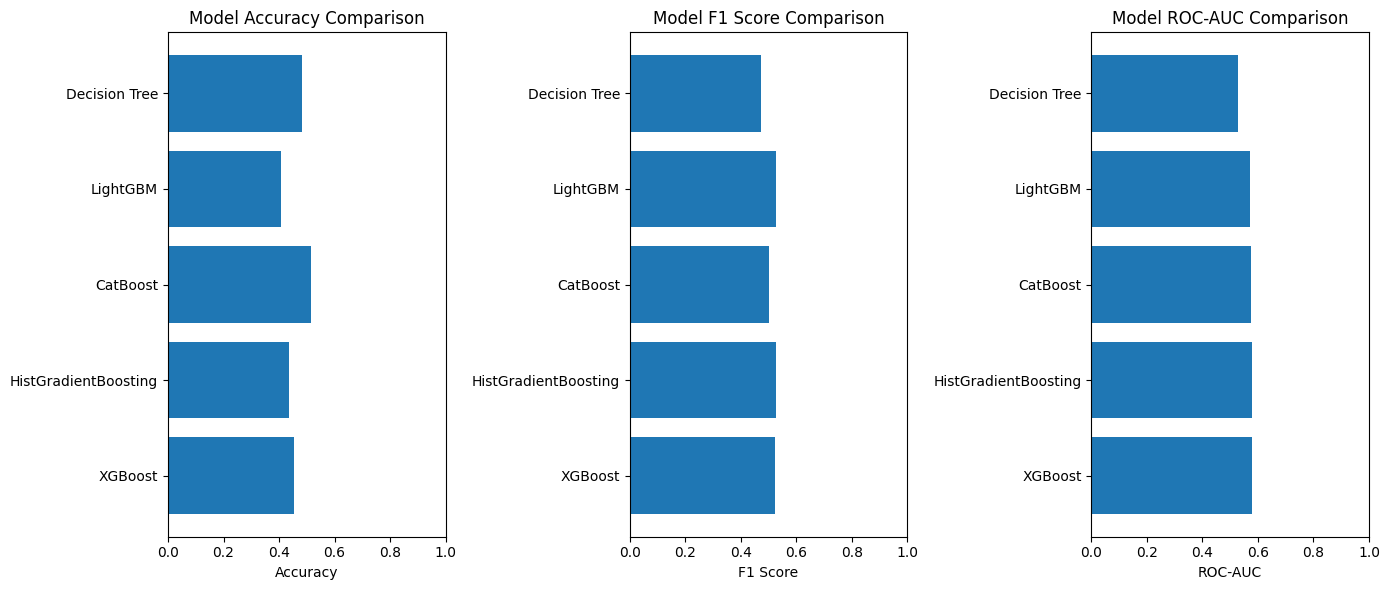


Best Model: XGBoost (ROC-AUC: 0.5778)


In [62]:
# Compare all models (binary classification) - Load models from saved files
import pickle
import glob
import os
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score

print("Loading all saved models and preparing for comparison...")
print("=" * 80)

# Find the most recent saved model files
model_files = {}
for model_type in ['lightgbm', 'xgboost', 'decision_tree', 'catboost', 'histgradientboosting']:
    files = glob.glob(f"saved_models/{model_type}_*.pkl")
    if files:
        # Get most recent file
        latest_file = max(files, key=os.path.getctime)
        model_files[model_type] = latest_file
        print(f"Found {model_type}: {os.path.basename(latest_file)}")
    else:
        print(f"No saved {model_type} model found!")

print("=" * 80)

# Load all models and their preprocessing components
loaded_models = {}
for model_type, filepath in model_files.items():
    with open(filepath, 'rb') as f:
        saved_data = pickle.load(f)
        loaded_models[model_type] = {
            'model': saved_data['model'],
            'scaler': saved_data.get('scaler', None),
            'encoders': saved_data.get('encoders', None),
            'historical_stats': saved_data.get('historical_stats', None),
            'feature_names': saved_data.get('feature_names', None),
            'threshold': saved_data.get('threshold', 0)
        }

# Check if we have test data available
if 'X_test' not in globals() or 'y_test' not in globals():
    print("\nTest data (X_test, y_test) not found in current session.")
    print("Run the data preparation cells first.")
    raise NameError("X_test and y_test must be available. Please run the data preparation cells.")

# Prepare test data for each model type (if needed, recreate from original data)
# For now, assuming X_test, X_test_encoded, X_test_scaled, X_test_cat are available

model_names = ['LightGBM', 'XGBoost', 'Decision Tree', 'CatBoost', 'HistGradientBoosting']
model_keys = ['lightgbm', 'xgboost', 'decision_tree', 'catboost', 'histgradientboosting']

# Make predictions with each loaded model
predictions_test = {}
probabilities_test = {}

for model_name, model_key in zip(model_names, model_keys):
    if model_key not in loaded_models:
        print(f"⚠️  Skipping {model_name} - model not loaded")
        continue
    
    model_data = loaded_models[model_key]
    model = model_data['model']
    
    # Select appropriate test data based on model type
    if model_key == 'lightgbm' or model_key == 'catboost':
        # Use categorical features
        if 'X_test_cat' in globals():
            X_test_for_model = X_test_cat.copy()
        else:
            X_test_for_model = X_test.copy()
            # Convert categoricals to category dtype
            cat_features = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE_BIN',
                           'HOUR_DAY_WEEK', 'AIRLINE_ROUTE']
            for col in cat_features:
                if col in X_test_for_model.columns:
                    X_test_for_model[col] = X_test_for_model[col].astype('category')
    elif model_key == 'decision_tree':
        # Use encoded and scaled features
        if 'X_test_scaled' in globals():
            X_test_for_model = X_test_scaled
        else:
            # Encode and scale if needed
            X_test_encoded = X_test.copy()
            if model_data['encoders']:
                for col, le in model_data['encoders'].items():
                    if col in X_test_encoded.columns:
                        val_series = X_test_encoded[col].astype(str)
                        val_mask = val_series.isin(le.classes_)
                        max_index = len(le.classes_) - 1
                        unknown_index = max_index + 1
                        test_encoded = np.full(len(val_series), unknown_index, dtype=int)
                        test_encoded[val_mask] = le.transform(val_series[val_mask])
                        X_test_encoded[col] = test_encoded
            if model_data['scaler']:
                X_test_for_model = model_data['scaler'].transform(X_test_encoded)
            else:
                X_test_for_model = X_test_encoded
    else:  # xgboost, histgradientboosting
        # Use encoded features
        if 'X_test_encoded' in globals():
            X_test_for_model = X_test_encoded.copy()
        else:
            # Encode if needed
            X_test_encoded = X_test.copy()
            if model_data['encoders']:
                for col, le in model_data['encoders'].items():
                    if col in X_test_encoded.columns:
                        val_series = X_test_encoded[col].astype(str)
                        val_mask = val_series.isin(le.classes_)
                        max_index = len(le.classes_) - 1
                        unknown_index = max_index + 1
                        test_encoded = np.full(len(val_series), unknown_index, dtype=int)
                        test_encoded[val_mask] = le.transform(val_series[val_mask])
                        X_test_encoded[col] = test_encoded
            X_test_for_model = X_test_encoded
    
    # Make predictions
    proba = model.predict_proba(X_test_for_model)
    probabilities_test[model_name] = proba[:, 1]  # Probability of delay class

print("\nPredictions made for all loaded models")

# Optimize thresholds on validation set (if available)
if 'X_val' in globals() and 'y_val' in globals():
    print("\nFinding optimal thresholds on validation set...")
    optimal_thresholds = {}
    thresholds_to_try = np.arange(0.1, 0.9, 0.01)
    
    for model_name, model_key in zip(model_names, model_keys):
        if model_key not in loaded_models:
            continue
        
        model_data = loaded_models[model_key]
        model = model_data['model']
        
        # Get validation predictions
        if model_key == 'lightgbm' or model_key == 'catboost':
            if 'X_val_cat' in globals():
                X_val_for_model = X_val_cat.copy()
            else:
                X_val_for_model = X_val.copy()
                cat_features = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE_BIN',
                               'HOUR_DAY_WEEK', 'AIRLINE_ROUTE']
                for col in cat_features:
                    if col in X_val_for_model.columns:
                        X_val_for_model[col] = X_val_for_model[col].astype('category')
        elif model_key == 'decision_tree':
            if 'X_val_scaled' in globals():
                X_val_for_model = X_val_scaled
            else:
                X_val_encoded = X_val.copy()
                if model_data['encoders']:
                    for col, le in model_data['encoders'].items():
                        if col in X_val_encoded.columns:
                            val_series = X_val_encoded[col].astype(str)
                            val_mask = val_series.isin(le.classes_)
                            max_index = len(le.classes_) - 1
                            unknown_index = max_index + 1
                            val_encoded = np.full(len(val_series), unknown_index, dtype=int)
                            val_encoded[val_mask] = le.transform(val_series[val_mask])
                            X_val_encoded[col] = val_encoded
                if model_data['scaler']:
                    X_val_for_model = model_data['scaler'].transform(X_val_encoded)
                else:
                    X_val_for_model = X_val_encoded
        else:
            if 'X_val_encoded' in globals():
                X_val_for_model = X_val_encoded.copy()
            else:
                X_val_encoded = X_val.copy()
                if model_data['encoders']:
                    for col, le in model_data['encoders'].items():
                        if col in X_val_encoded.columns:
                            val_series = X_val_encoded[col].astype(str)
                            val_mask = val_series.isin(le.classes_)
                            max_index = len(le.classes_) - 1
                            unknown_index = max_index + 1
                            val_encoded = np.full(len(val_series), unknown_index, dtype=int)
                            val_encoded[val_mask] = le.transform(val_series[val_mask])
                            X_val_encoded[col] = val_encoded
                X_val_for_model = X_val_encoded
        
        y_proba_val = model.predict_proba(X_val_for_model)[:, 1]
        
        # Find optimal threshold
        best_threshold = 0.5
        best_f1 = 0
        for threshold in thresholds_to_try:
            y_pred_thresh = (y_proba_val >= threshold).astype(int)
            f1 = f1_score(y_val, y_pred_thresh)
            if f1 > best_f1:
                best_f1 = f1
                best_threshold = threshold
        
        optimal_thresholds[model_name] = best_threshold
    
    print("Optimal thresholds calculated")
else:
    print("\n⚠️  Validation data not available. Using default threshold of 0.5 for all models.")
    optimal_thresholds = {name: 0.5 for name in model_names if name in probabilities_test}

# Apply optimal thresholds to get binary predictions
predictions_test_opt = {}
for model_name in model_names:
    if model_name in probabilities_test:
        predictions_test_opt[model_name] = (probabilities_test[model_name] >= optimal_thresholds.get(model_name, 0.5)).astype(int)

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)

# Compare all models
models = [name for name in model_names if name in predictions_test_opt]
predictions = [predictions_test_opt[name] for name in models]
probabilities = [probabilities_test[name] for name in models]

results = []
for model_name, y_pred, y_proba in zip(models, predictions, probabilities):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    results.append({
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    })

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('ROC-AUC', ascending=False)

# Get delay threshold from loaded models (should be the same for all)
delay_threshold = loaded_models[list(loaded_models.keys())[0]]['threshold'] if loaded_models else 0

print("Model Comparison (Test Set - Binary Classification):")
print(f"Delay Threshold: >{delay_threshold} minutes")
print("Using optimized prediction thresholds (maximizing F1 score)")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# Show optimal thresholds used
print("\nOptimal Thresholds Used (determined on validation set):")
for model_name in models:
    print(f"  {model_name:20s}: {optimal_thresholds[model_name]:.3f}")
print("=" * 80)

# Visualize comparison
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
plt.barh(comparison_df['Model'], comparison_df['Accuracy'])
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlim([0, 1])

plt.subplot(1, 3, 2)
plt.barh(comparison_df['Model'], comparison_df['F1 Score'])
plt.xlabel('F1 Score')
plt.title('Model F1 Score Comparison')
plt.xlim([0, 1])

plt.subplot(1, 3, 3)
plt.barh(comparison_df['Model'], comparison_df['ROC-AUC'])
plt.xlabel('ROC-AUC')
plt.title('Model ROC-AUC Comparison')
plt.xlim([0, 1])

plt.tight_layout()
plt.show()

print(f"\nBest Model: {comparison_df.iloc[0]['Model']} (ROC-AUC: {comparison_df.iloc[0]['ROC-AUC']:.4f})")


## Step 6: Make Predictions on New Flight Data

Use this cell to predict flight delays for new flights using the trained models.


In [59]:
# Load saved models and make predictions on new flight data

# User input - modify this dictionary with your flight details
user_flight = {
    'MONTH': 7,              # Month (1-12)
    'DAY': 10,               # Day of month (1-31)
    'DAY_OF_WEEK': 4,        # Day of week (1=Monday, 7=Sunday)
    'HOUR': 14,              # Hour of departure (0-23)
    'AIRLINE': 'AA',         # Airline code (e.g., AA, DL, UA, WN, etc.)
    'ORIGIN_AIRPORT': 'ORD', # Origin airport code
    'DESTINATION_AIRPORT': 'MIA',  # Destination airport code
    'DISTANCE': 1197,        # Flight distance in miles
    'SCHEDULED_TIME': 160,   # Scheduled flight time in minutes
    # Note: AIRLINE_POPULARITY, ORIGIN_TRAFFIC, DEST_TRAFFIC are not used as users would not usually know
}

# Select which model to use (options: 'lightgbm', 'xgboost', 'decision_tree', 'catboost', 'histgradientboosting')
selected_model = 'xgboost'  # Change this to use a different model

print("=" * 70)
print("FLIGHT DELAY PREDICTION")
print("=" * 70)
print(f"\nFlight Details:")
for key, value in user_flight.items():
    print(f"  {key:20s}: {value}")

# Find the most recent saved model files
import glob
model_files = {}
for model_type in ['lightgbm', 'xgboost', 'decision_tree', 'catboost', 'histgradientboosting']:
    files = glob.glob(f"saved_models/{model_type}_*.pkl")
    if files:
        # Get most recent file
        latest_file = max(files, key=os.path.getctime)
        model_files[model_type] = latest_file

if selected_model not in model_files:
    print(f"\Error: No saved {selected_model} model found")
    print(f"Available models: {list(model_files.keys())}")
else:
    print(f"\nLoading model: {selected_model}")
    print(f"File: {model_files[selected_model]}")
    
    # Load the model
    with open(model_files[selected_model], 'rb') as f:
        saved_data = pickle.load(f)
    
    model = saved_data['model']
    historical_stats = saved_data['historical_stats']
    encoders = saved_data.get('encoders', None)
    scaler = saved_data.get('scaler', None)
    feature_names = saved_data['feature_names']
    threshold = saved_data.get('threshold', 0)
    optimal_threshold = optimal_thresholds.get(selected_model.replace('_', ' ').title(), 0.5) if 'optimal_thresholds' in globals() else 0.5
    
    print(f"✓ Model loaded successfully")
    
    # Create df from user input
    flight_df = pd.DataFrame([user_flight])
    
    # Feature Engineering for user input to match the training data
    
    # 1. Extract hour (if not already provided)
    if 'SCHEDULED_DEPARTURE' in flight_df.columns and 'HOUR' not in flight_df.columns:
        flight_df['HOUR'] = (flight_df['SCHEDULED_DEPARTURE'] // 100).astype(int).clip(0, 23)
    
    # 2. Create route
    flight_df['ROUTE'] = flight_df['ORIGIN_AIRPORT'].astype(str) + '-' + flight_df['DESTINATION_AIRPORT'].astype(str)
    
    # 3. Cyclical encoding
    flight_df['HOUR_SIN'] = np.sin(2 * np.pi * flight_df['HOUR'] / 24)
    flight_df['HOUR_COS'] = np.cos(2 * np.pi * flight_df['HOUR'] / 24)
    flight_df['DAY_OF_WEEK_SIN'] = np.sin(2 * np.pi * flight_df['DAY_OF_WEEK'] / 7)
    flight_df['DAY_OF_WEEK_COS'] = np.cos(2 * np.pi * flight_df['DAY_OF_WEEK'] / 7)
    flight_df['MONTH_SIN'] = np.sin(2 * np.pi * flight_df['MONTH'] / 12)
    flight_df['MONTH_COS'] = np.cos(2 * np.pi * flight_df['MONTH'] / 12)
    
    # 4. Distance bins
    flight_df['DISTANCE_BIN'] = pd.cut(flight_df['DISTANCE'], 
                                      bins=[0, 500, 1500, 10000], 
                                      labels=['SHORT', 'MEDIUM', 'LONG']).astype(str)
    
    # 5. Interaction features
    flight_df['HOUR_DAY_WEEK'] = flight_df['HOUR'].astype(str) + '_' + flight_df['DAY_OF_WEEK'].astype(str)
    flight_df['AIRLINE_ROUTE'] = flight_df['AIRLINE'].astype(str) + '_' + flight_df['ROUTE'].astype(str)
    
    # 6. Historical statistics (using saved stats)
    stats = historical_stats
    airline = user_flight['AIRLINE']
    origin = user_flight['ORIGIN_AIRPORT']
    dest = user_flight['DESTINATION_AIRPORT']
    route = flight_df['ROUTE'].iloc[0]
    hour = user_flight['HOUR']
    dow = user_flight['DAY_OF_WEEK']
    
    flight_df['AIRLINE_AVG_DELAY'] = stats['airline_avg_delay'].get(airline, stats['overall_mean'])
    flight_df['ORIGIN_AVG_DELAY'] = stats['origin_avg_delay'].get(origin, stats['overall_mean'])
    flight_df['DEST_AVG_DELAY'] = stats['dest_avg_delay'].get(dest, stats['overall_mean'])
    flight_df['ROUTE_AVG_DELAY'] = stats['route_avg_delay'].get(route, stats['overall_mean'])
    flight_df['AIRLINE_MEDIAN_DELAY'] = stats['airline_median_delay'].get(airline, stats['overall_mean'])
    flight_df['ROUTE_MEDIAN_DELAY'] = stats['route_median_delay'].get(route, stats['overall_mean'])
    flight_df['AIRLINE_STD_DELAY'] = stats['airline_std_delay'].get(airline, stats['overall_std'])
    flight_df['ROUTE_STD_DELAY'] = stats['route_std_delay'].get(route, stats['overall_std'])
    
    # 7. Route-specific temporal patterns
    route_hour_key = (route, hour)
    route_dow_key = (route, dow)
    flight_df['ROUTE_HOUR_AVG'] = stats['route_hour_avg'].get(route_hour_key, stats['route_avg_delay'].get(route, stats['overall_mean']))
    flight_df['ROUTE_DOW_AVG'] = stats['route_dow_avg'].get(route_dow_key, stats['route_avg_delay'].get(route, stats['overall_mean']))
    
    # 8. Airport congestion features
    origin_hour_key = (origin, hour)
    dest_hour_key = (dest, hour)
    flight_df['ORIGIN_HOUR_COUNT'] = stats['origin_hour_count'].get(origin_hour_key, 0)
    flight_df['DEST_HOUR_COUNT'] = stats['dest_hour_count'].get(dest_hour_key, 0)
    
    # 9. Flight efficiency
    flight_df['SPEED_MILES_PER_MIN'] = flight_df['DISTANCE'] / flight_df['SCHEDULED_TIME'].replace(0, 1)
    
    print("Feature engineering completed")
    
    # Select features in the same order as training
    X_pred = flight_df[feature_names].copy()
    
    # Preprocess based on model type
    if selected_model == 'decision_tree':
        # Encode categoricals and scale
        X_pred_encoded = X_pred.copy()
        if encoders:
            for col, le in encoders.items():
                if col in X_pred_encoded.columns:
                    val = str(X_pred_encoded[col].iloc[0])
                    if val in le.classes_:
                        X_pred_encoded[col] = le.transform([val])[0]
                    else:
                        # Map to UNKNOWN category
                        max_index = len(le.classes_) - 1
                        X_pred_encoded[col] = max_index + 1
        
        # Scale features
        X_pred_scaled = scaler.transform(X_pred_encoded)
        X_final = X_pred_scaled
        
    elif selected_model in ['xgboost', 'histgradientboosting']:
        # Encode categoricals as these need it
        X_pred_encoded = X_pred.copy()
        if encoders:
            for col, le in encoders.items():
                if col in X_pred_encoded.columns:
                    val = str(X_pred_encoded[col].iloc[0])
                    if val in le.classes_:
                        X_pred_encoded[col] = le.transform([val])[0]
                    else:
                        # Map to UNKNOWN category
                        max_index = len(le.classes_) - 1
                        X_pred_encoded[col] = max_index + 1
        X_final = X_pred_encoded
        
    elif selected_model in ['lightgbm', 'catboost']:
        # Convert categoricals to category dtype
        cat_features = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DISTANCE_BIN',
                       'HOUR_DAY_WEEK', 'AIRLINE_ROUTE']
        for col in cat_features:
            if col in X_pred.columns:
                X_pred[col] = X_pred[col].astype('category')
        X_final = X_pred
        
    else:
        X_final = X_pred
    
    print("Preprocessing completed")
    
    # Make prediction
    print(f"\nMaking prediction...")
    proba = model.predict_proba(X_final)[0]
    prediction_prob = proba[1]  # Probability of delay
    prediction_binary = (prediction_prob >= optimal_threshold).astype(int)
    
    print("=" * 70)
    print("PREDICTION RESULTS")
    print("=" * 70)
    print(f"Model: {selected_model.upper()}")
    print(f"Prediction threshold: {optimal_threshold:.3f}")
    print(f"\nProbability of delay: {prediction_prob:.4f} ({prediction_prob*100:.2f}%)")
    print(f"Predicted class: {'DELAYED' if prediction_binary == 1 else 'ON-TIME/EARLY'}")
    print(f"\nInterpretation:")
    if prediction_binary == 1:
        print(f"This flight is predicted to be DELAYED (ARRIVAL_DELAY > {threshold} minutes)")
    else:
        print(f"This flight is predicted to be ON-TIME or EARLY (ARRIVAL_DELAY <= {threshold} minutes)")
    print("=" * 70)


FLIGHT DELAY PREDICTION

Flight Details:
  MONTH               : 7
  DAY                 : 10
  DAY_OF_WEEK         : 4
  HOUR                : 14
  AIRLINE             : AA
  ORIGIN_AIRPORT      : ORD
  DESTINATION_AIRPORT : MIA
  DISTANCE            : 1197
  SCHEDULED_TIME      : 160

Loading model: xgboost
File: saved_models/xgboost_20251031_120240.pkl
✓ Model loaded successfully
Feature engineering completed
Preprocessing completed

Making prediction...
PREDICTION RESULTS
Model: XGBOOST
Prediction threshold: 0.500

Probability of delay: 0.7779 (77.79%)
Predicted class: DELAYED

Interpretation:
This flight is predicted to be DELAYED (ARRIVAL_DELAY > 0 minutes)


<>:38: SyntaxWarning: invalid escape sequence '\E'
<>:38: SyntaxWarning: invalid escape sequence '\E'
/var/folders/g5/4yhn68xj2ks9ghkkthvs4n5w0000gn/T/ipykernel_64357/3000286433.py:38: SyntaxWarning: invalid escape sequence '\E'
  print(f"\Error: No saved {selected_model} model found")
